In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("Telco_customer_churn.xlsx")

### Data Validation & Basic Audit

In [3]:
df.shape

(7043, 33)

**Total 7043 rows and 33 columns**

In [4]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='str')

**Coulmn 'CustomerID' is representing as an ID**

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

**All columns have 7043 count that is non-null values except 'Churn Reason' column which has 1869 entries**

In [6]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


**Target column is 'Churn Label' which does not have null values and has 'Yes/No' values**

In [7]:
df["Total Charges"]

0        108.15
1        151.65
2         820.5
3       3046.05
4        5036.3
         ...   
7038     1419.4
7039     1990.5
7040     7362.9
7041     346.45
7042     6844.5
Name: Total Charges, Length: 7043, dtype: object

**Total Charges column data type is 'object' but has numeric float values because there might be some values which are other than numeric value**

In [8]:
df["Total Charges"].isna().sum()

np.int64(0)

**Total Charges column does not have any null or NaN values**

Observation 1 — Why does "Churn Reason" have many nulls?

In [9]:
df["Churn Reason"].count()

np.int64(1869)

In [10]:
df[df["Churn Label" ] == "Yes"].shape[0]

1869

**Row count with 'Churn Label' is Yes is 1869 so "Churn Reason" will only populate where Churn Label is Yes"**

Observation 2 — TotalCharges as Object

In [11]:
total_charges_transform = pd.to_numeric(df["Total Charges"], errors="coerce")

In [12]:
total_charges_transform.isna().sum()

np.int64(11)

In [13]:
df[total_charges_transform.isna()]

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
2234,4472-LVYGI,1,United States,California,San Bernardino,92408,"34.084909, -117.258107",34.084909,-117.258107,Female,...,Two year,Yes,Bank transfer (automatic),52.55,,No,0,36,2578,NaN
2438,3115-CZMZD,1,United States,California,Independence,93526,"36.869584, -118.189241",36.869584,-118.189241,Male,...,Two year,No,Mailed check,20.25,,No,0,68,5504,NaN
2568,5709-LVOEQ,1,United States,California,San Mateo,94401,"37.590421, -122.306467",37.590421,-122.306467,Female,...,Two year,No,Mailed check,80.85,,No,0,45,2048,NaN
2667,4367-NUYAO,1,United States,California,Cupertino,95014,"37.306612, -122.080621",37.306612,-122.080621,Male,...,Two year,No,Mailed check,25.75,,No,0,48,4950,NaN
2856,1371-DWPAZ,1,United States,California,Redcrest,95569,"40.363446, -123.835041",40.363446,-123.835041,Female,...,Two year,No,Credit card (automatic),56.05,,No,0,30,4740,NaN
4331,7644-OMVMY,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,...,Two year,No,Mailed check,19.85,,No,0,53,2019,NaN
4687,3213-VVOLG,1,United States,California,Sun City,92585,"33.739412, -117.173334",33.739412,-117.173334,Male,...,Two year,No,Mailed check,25.35,,No,0,49,2299,NaN
5104,2520-SGTTA,1,United States,California,Ben Lomond,95005,"37.078873, -122.090386",37.078873,-122.090386,Female,...,Two year,No,Mailed check,20.00,,No,0,27,3763,NaN
5719,2923-ARZLG,1,United States,California,La Verne,91750,"34.144703, -117.770299",34.144703,-117.770299,Male,...,One year,Yes,Mailed check,19.70,,No,0,69,4890,NaN
6772,4075-WKNIU,1,United States,California,Bell,90201,"33.970343, -118.171368",33.970343,-118.171368,Female,...,Two year,No,Mailed check,73.35,,No,0,44,2342,NaN


In [14]:
df[total_charges_transform.isna()]["Tenure Months"]

2234    0
2438    0
2568    0
2667    0
2856    0
4331    0
4687    0
5104    0
5719    0
6772    0
6840    0
Name: Tenure Months, dtype: int64

**After converting "Total Charges" column to numeric, 11 of them became NaN. Upon checking the tenure column, their tenure was 0**  
**Inference:**
- They might be newly joined customers who are not billed yet

In [15]:
df[["Tenure Months", "Monthly Charges", "Total Charges"]].head()

,Tenure Months,Monthly Charges,Total Charges
0,2,53.85,108.15
1,2,70.70,151.65
2,8,99.65,820.5
3,28,104.80,3046.05
4,49,103.70,5036.3


In [16]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

In [17]:
df["Total Charges"].isna().sum()

np.int64(11)

In [18]:
df[df["Total Charges"].isna()].head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
2234,4472-LVYGI,1,United States,California,San Bernardino,92408,"34.084909, -117.258107",34.084909,-117.258107,Female,...,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,0,36,2578,NaN
2438,3115-CZMZD,1,United States,California,Independence,93526,"36.869584, -118.189241",36.869584,-118.189241,Male,...,Two year,No,Mailed check,20.25,NaN,No,0,68,5504,NaN
2568,5709-LVOEQ,1,United States,California,San Mateo,94401,"37.590421, -122.306467",37.590421,-122.306467,Female,...,Two year,No,Mailed check,80.85,NaN,No,0,45,2048,NaN
2667,4367-NUYAO,1,United States,California,Cupertino,95014,"37.306612, -122.080621",37.306612,-122.080621,Male,...,Two year,No,Mailed check,25.75,NaN,No,0,48,4950,NaN
2856,1371-DWPAZ,1,United States,California,Redcrest,95569,"40.363446, -123.835041",40.363446,-123.835041,Female,...,Two year,No,Credit card (automatic),56.05,NaN,No,0,30,4740,NaN


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [20]:
df["Total Charges"].isna().sum()

np.int64(11)

In [21]:
df["Total Charges"] = df["Total Charges"].fillna(0)

In [22]:
df["Total Charges"].isna().sum()

np.int64(0)

In [23]:
df.shape

(7043, 33)

**Data Cleaning Summary:**  
- Total Charges was incorrectly stored as object
- 11 blank values detected after numeric coercion
- All 11 had Tenure Months = 0
- Replaced NaN with 0 based on business logic
- Final datatype → float64
- No rows dropped
- Dataset shape intact → (7043, 33)

### Target Variable & Class Imbalance

**🔹 Task 1 — Examine Target Variable**  

Check:
1. Unique values in Churn Label
2. Count of each class
3. Percentage of churn vs non-churn

Report:
1. Number of churned customers = 1869
2. Number of retained customers = 5174
3. Churn rate (%) = 26.54 %

In [24]:
df["Churn Label"].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [25]:
churned_customers = df[df["Churn Label"] == "Yes"].shape[0]
print(churned_customers)

1869


In [26]:
retained_customers = df[df["Churn Label"] == "No"].shape[0]
print(retained_customers)

5174


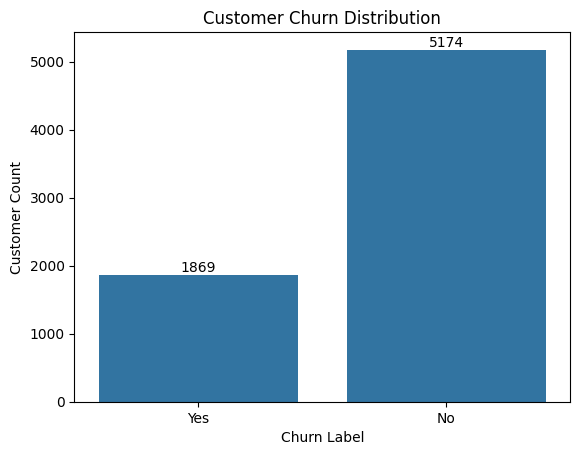

In [220]:
# Churn Distribution Visualization
ax = sns.countplot(data=df, x="Churn Label")

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title("Customer Churn Distribution")
plt.ylabel("Customer Count")
plt.show()

In [28]:
total_customers = df["CustomerID"].count()
print(total_customers)

7043


In [29]:
churn_rate = (churned_customers / total_customers) * 100
print(round(churn_rate, 2))

26.54


1. Is churn rate high or moderate?  
**26.54 % looks high since it is above 20 %**
2. If you were presenting to management, how would you describe this churn level?  
**With a churn rate of 26.5%, around 1 in 4 customers are leaving the company. This churn rate is high for the telecom company and provides high risks in customer acquisition cost and business revenue loss**
3. Is dataset balanced or imbalanced?  
**Since 26.5% churn, dataset is moderately imbalanced**

**Calculate revenue impact of churn:**  

Total revenue from churned customers  
2862926.9  

Total revenue from retained customers  
13193241.8  

Average monthly charges (churned vs retained)  
churned = 74.44 vs retained = 61.27  
Churned customers are paying more per month on average.  
**Insights** - 
1. Higher-paying customers are more likely to churn.  
2. Churned customers have significantly higher monthly charges compared to retained customers. This suggests pricing sensitivity or dissatisfaction among premium-paying customers.

In [30]:
print(df[df["Churn Label"] == "Yes"]["Total Charges"].sum())

2862926.9


In [31]:
print(df[df["Churn Label"] == "No"]["Total Charges"].sum())

13193241.8


In [32]:
print(round(df[df["Churn Label"] == "Yes"]["Monthly Charges"].mean(), 2))
print(round(df[df["Churn Label"] == "No"]["Monthly Charges"].mean(), 2))

74.44
61.27


Now analyze churn rate by:

Contract Type  
Internet Service Type

Count total customers per contract type.

Count churned customers per contract type.

Divide churned / total_per_contract.

Report updated table.

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [34]:
df["Contract"].unique()

<StringArray>
['Month-to-month', 'Two year', 'One year']
Length: 3, dtype: str

In [35]:
# Total churned customers
len(df[df["Churn Label"] == "Yes"])

1869

In [188]:
# Total month-to-month contract customers
month_to_month_customers = len(df[df["Contract"] == 'Month-to-month'])
month_to_month_customers

3875

In [189]:
# Total churned customers in month-to-month contract customers
month_to_month_customers_churn = len(df[(df["Contract"] == 'Month-to-month') & (df["Churn Label"] == "Yes")])
month_to_month_customers_churn

1655

In [190]:
# churn rate for such category
month_to_month_customers_churn_rate = round((len(df[(df["Contract"] == 'Month-to-month') & (df["Churn Label"] == "Yes")]) / len(df[df["Contract"] == 'Month-to-month'])) * 100, 2)
month_to_month_customers_churn_rate

42.71

In [191]:
# Total One year contract customers
one_year_customers = len(df[df["Contract"] == 'One year'])
one_year_customers

1473

In [192]:
# Total churned customers in One year contract customers
one_year_customers_churn = len(df[(df["Contract"] == 'One year') & (df["Churn Label"] == "Yes")])
one_year_customers_churn

166

In [193]:
# churn rate for such category
one_year_customers_churn_rate = round((len(df[(df["Contract"] == 'One year') & (df["Churn Label"] == "Yes")]) / len(df[df["Contract"] == 'One year']) * 100), 2)
one_year_customers_churn_rate

11.27

In [194]:
# Total Two year contract customers
two_year_customers = len(df[df["Contract"] == 'Two year'])
two_year_customers

1695

In [195]:
# Total churned customers in Two year contract customers
two_year_customers_churn = len(df[(df["Contract"] == 'Two year') & (df["Churn Label"] == "Yes")])
two_year_customers_churn

48

In [196]:
# Percentage churn rate for Two year contract customers
two_year_customers_churn_rate = round((len(df[(df["Contract"] == 'Two year') & (df["Churn Label"] == "Yes")]) / len(df[df["Contract"] == 'Two year']) * 100), 2)
two_year_customers_churn_rate

2.83

Actionable business decisions based on analysis:
- Incentivizing long-term contracts.
- Offer discounts for 1-year/2-year plans for customer lifecycle value.
- Targeting month-to-month customers for retention.
- Predicting churn risk based on contract type  

In [206]:
# Visualization - Contract Type vs Churn Rate
contract_group = df.groupby("Contract")

total_customers = contract_group["CustomerID"].count()
churned_customers = contract_group["Churn Label"].apply(lambda x: (x == "Yes").sum())

contract_churn = pd.DataFrame({
    "Total Customers": total_customers,
    "Churned": churned_customers
})

contract_churn["Churn Rate (%)"] = (
    contract_churn["Churned"] / contract_churn["Total Customers"] * 100
)

contract_churn = contract_churn.reset_index()

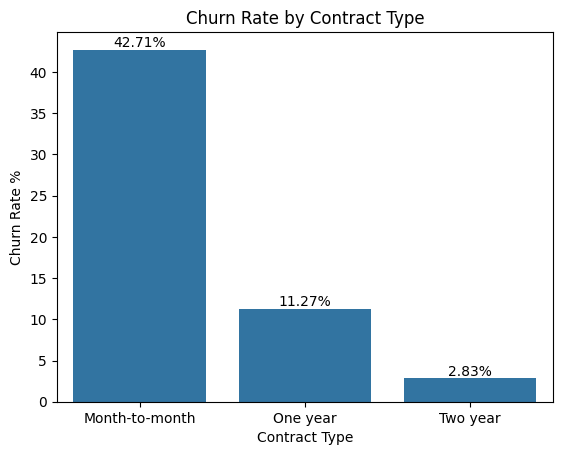

In [209]:
ax = sns.barplot(data=contract_churn, x="Contract", y="Churn Rate (%)")

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate %")
plt.show()

In [45]:
# Values for Internet Service type
df["Internet Service"].unique()

<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

In [46]:
# Total customers with DSL internet service
len(df[df["Internet Service"] == "DSL"])

2421

In [47]:
# Total customers with DSL internet and churned customers
len(df[(df["Internet Service"] == "DSL") & (df["Churn Label"] == "Yes")])

459

In [48]:
# Percentage of churned customers with DSL internet service type
round(((len(df[(df["Internet Service"] == "DSL") & (df["Churn Label"] == "Yes")]) / len(df[df["Internet Service"] == "DSL"]))) * 100, 2)

18.96

In [202]:
# Total customers with Fiber optic internet service
len(df[df["Internet Service"] == "Fiber optic"])

3096

In [50]:
# Total customers with Fiber optic internet and churned customers
len(df[(df["Internet Service"] == "Fiber optic") & (df["Churn Label"] == "Yes")])

1297

In [51]:
# Percentage of churned customers with Fiber optic internet service type
round(((len(df[(df["Internet Service"] == "Fiber optic") & (df["Churn Label"] == "Yes")]) / len(df[df["Internet Service"] == "Fiber optic"]))) * 100, 2)

41.89

In [52]:
# Total customers with No internet service
len(df[df["Internet Service"] == "No"])

1526

In [53]:
# Total customers with No internet and churned customers
len(df[(df["Internet Service"] == "No") & (df["Churn Label"] == "Yes")])

113

In [54]:
# Percentage of churned customers with No internet service type
round(((len(df[(df["Internet Service"] == "No") & (df["Churn Label"] == "Yes")]) / len(df[df["Internet Service"] == "No"]))) * 100, 2)

7.4

Contract Type  
Contract Type  | Total Customers | Churned | Churn Rate %  
Month-to-month | 3875            | 1655    | 42.71 %  
One year       | 1473            | 166     | 11.27 %  
Two year       | 1695            | 48      | 2.83 %  
**Customers on month-to-month contracts exhibit significantly higher churn (42.7%) compared to one-year (11.3%) and two-year contracts (2.8%). This strongly suggests that longer-term contractual commitments are associated with improved customer retention.**  

Internet Service Type  
Internet Service Type | Total Customers | Churned | Churn Rate %  
DSL                   | 2421            | 459     | 18.96 %    
Fiber optic           | 3096            | 1297    | 41.89 %  
No Internet           | 1526            | 113     | 7.4 %  
**Customers with Fiber optic internet service show a higher churn (41.89%) compared to DSL (18.96%) and No internet service (7.4%)**

**Business Logic Behind Hypothesis**  

Fiber customers likely experience:  
- Higher monthly charges
- More price sensitivity
- Easier switching (no contract lock-in)

So if:  
Customer pays high price  
AND  
Customer is not contract-locked  

**→ churn probability increases.**  

**Need to calculate churn rate for all combinations to check with combination is getting hit with churn**  
Internet Services  
- Fiber optic
- DSL
- No Internet

Contract Types  
- Month-to-month
- One year
- Two year

Need to test this hypothesis with numbers, formula:  
**Churn Rate = Churned Customers / Total Customers**

**Hypothesis verification -** Fiber + Month-to-month combination churn rate

In [55]:
# Total customers with Fiber optic internet connection and Month-to-month contract
fiber_m2m_customers = len(df[(df["Internet Service"] == "Fiber optic") & (df["Contract"] == "Month-to-month")])
fiber_m2m_customers

2128

In [56]:
# Define total churned customers for this segment
fiber_m2m_churned_customers = len(df[(df["Churn Label"] == "Yes") & (df["Contract"] == "Month-to-month") & (df["Internet Service"] == "Fiber optic")])
fiber_m2m_churned_customers

1162

In [57]:
# Churn rate of such customers
fiber_m2m_churned_customers_rate = round(((fiber_m2m_churned_customers / fiber_m2m_customers) * 100), 2)
fiber_m2m_churned_customers_rate

54.61

**Hypothesis verification -** Fiber + One year combination churn rate

In [58]:
# Total customers with Fiber optic internet connection and One year contract
fiber_oneyear_customers = len(df[(df["Internet Service"] == "Fiber optic") & (df["Contract"] == "One year")])
fiber_oneyear_customers

539

In [59]:
# Define total churned customers for this segment
oneyear_m2m_churned_customers = len(df[(df["Churn Label"] == "Yes") & (df["Contract"] == "One year") & (df["Internet Service"] == "Fiber optic")])
oneyear_m2m_churned_customers

104

In [60]:
# Churn rate of such customers
oneyear_m2m_churned_customers_rate = round(((oneyear_m2m_churned_customers / fiber_oneyear_customers) * 100), 2)
oneyear_m2m_churned_customers_rate

19.29

**Hypothesis verification -** Fiber + Two year combination churn rate

In [61]:
# Total customers with Fiber optic internet connection and Two year contract
twoyear_fiber_customers = len(df[(df["Internet Service"] == "Fiber optic") & (df["Contract"] == "Two year")])
twoyear_fiber_customers

429

In [62]:
# Define total churned customers for this segment
twoyear_fiber_churned_customers = len(df[(df["Churn Label"] == "Yes") & (df["Contract"] == "Two year") & (df["Internet Service"] == "Fiber optic")])
twoyear_fiber_churned_customers

31

In [63]:
# Churn rate of such customers
twoyear_fiber_churned_customers_rate = round(((twoyear_fiber_churned_customers / twoyear_fiber_customers) * 100), 2)
twoyear_fiber_churned_customers_rate

7.23

**Hypothesis verification -** DSL + Month-to-month combination churn rate

In [64]:
# Total customers with DSL internet connection and Month-to-month contract
dsl_m2m_customers = len(df[(df["Internet Service"] == "DSL") & (df["Contract"] == "Month-to-month")])
dsl_m2m_customers

1223

In [65]:
# Define total churned customers for this segment
dsl_m2m_churned_customers = len(df[(df["Churn Label"] == "Yes") & (df["Contract"] == "Month-to-month") & (df["Internet Service"] == "DSL")])
dsl_m2m_churned_customers

394

In [66]:
# Churn rate of such customers
dsl_m2m_churned_customers_rate = round(((dsl_m2m_churned_customers / dsl_m2m_customers) * 100), 2)
dsl_m2m_churned_customers_rate

32.22

**Hypothesis verification -** DSL + One year combination churn rate

In [67]:
# Total customers with DSL internet connection and One year contract
dsl_oneyear_customers = len(df[(df["Internet Service"] == "DSL") & (df["Contract"] == "One year")])
dsl_oneyear_customers

570

In [68]:
# Define total churned customers for this segment
dsl_oneyear_churned_customers = len(df[(df["Churn Label"] == "Yes") & (df["Contract"] == "One year") & (df["Internet Service"] == "DSL")])
dsl_oneyear_churned_customers

53

In [69]:
# Churn rate of such customers
dsl_oneyear_churned_customers_rate = round(((dsl_oneyear_churned_customers / dsl_oneyear_customers) * 100), 2)
dsl_oneyear_churned_customers_rate

9.3

**Hypothesis verification -** DSL + Two year combination churn rate

In [70]:
# Total customers with DSL internet connection and Two year contract
dsl_twoyear_customers = len(df[(df["Internet Service"] == "DSL") & (df["Contract"] == "Two year")])
dsl_twoyear_customers

628

In [71]:
# Define total churned customers for this segment
dsl_twoyear_churned_customers = len(df[(df["Churn Label"] == "Yes") & (df["Contract"] == "Two year") & (df["Internet Service"] == "DSL")])
dsl_twoyear_churned_customers

12

In [72]:
# Churn rate of such customers
dsl_twoyear_churned_customers_rate = round(((dsl_twoyear_churned_customers / dsl_twoyear_customers) * 100), 2)
dsl_twoyear_churned_customers_rate

1.91

**Hypothesis verification -** No Internet + Month-to-month combination churn rate

In [73]:
# Total customers with No internet connection and Month-to-month contract
no_m2m_customers = len(df[(df["Internet Service"] == "No") & (df["Contract"] == "Month-to-month")])
no_m2m_customers

524

In [74]:
# Define total churned customers for this segment
no_m2m_churned_customers = len(df[(df["Churn Label"] == "Yes") & (df["Contract"] == "Month-to-month") & (df["Internet Service"] == "No")])
no_m2m_churned_customers

99

In [75]:
# Churn rate of such customers
no_m2m_churned_customers_rate = round(((no_m2m_churned_customers / no_m2m_customers) * 100), 2)
no_m2m_churned_customers_rate

18.89

**Hypothesis verification -** No Internet + One year combination churn rate

In [76]:
# Total customers with No internet connection and One year contract
nointernet_oneyear_customers = len(df[(df["Internet Service"] == "No") & (df["Contract"] == "One year")])
nointernet_oneyear_customers

364

In [77]:
# Define total churned customers for this segment
no_oneyear_churned_customers = len(df[(df["Churn Label"] == "Yes") & (df["Contract"] == "One year") & (df["Internet Service"] == "No")])
no_oneyear_churned_customers

9

In [78]:
# Churn rate of such customers
no_oneyear_churned_customers_rate = round(((no_oneyear_churned_customers / nointernet_oneyear_customers) * 100), 2)
no_oneyear_churned_customers_rate

2.47

**Hypothesis verification -** No Internet + Two year combination churn rate

In [79]:
# Total customers with No internet connection and Two year contract
nointernet_twoyear_customers = len(df[(df["Internet Service"] == "No") & (df["Contract"] == "Two year")])
nointernet_twoyear_customers

638

In [80]:
# Define total churned customers for this segment
no_twoyear_churned_customers = len(df[(df["Churn Label"] == "Yes") & (df["Contract"] == "Two year") & (df["Internet Service"] == "No")])
no_twoyear_churned_customers

5

In [81]:
# Churn rate of such customers
no_twoyear_churned_customers_rate = round(((no_twoyear_churned_customers / nointernet_twoyear_customers) * 100), 2)
no_twoyear_churned_customers_rate

0.78

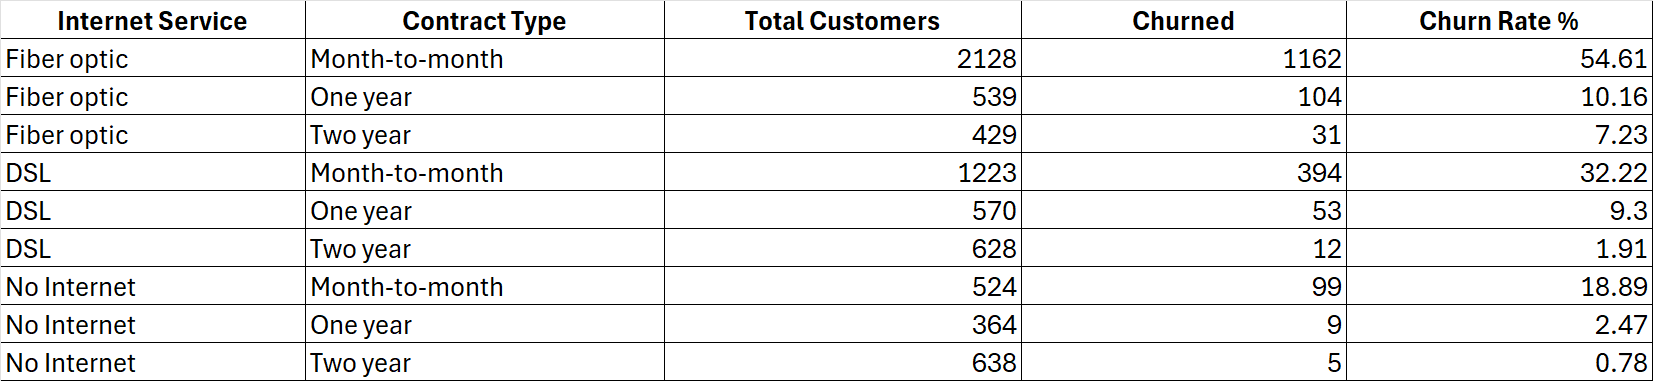

**Business Insights:**  
1. Churn Rate of month-to-month contract customers for all types of internet services is high, with Fiber + Month-to-month is the highest risk.
    - Fiber + Month-to-month → 54.61%
    - DSL + Month-to-month → 32.22%
    - No-internet + Month-to-month → 18.89%
2. Longer the contract, results in lower churn rates, with churn rate dropping from 54.61 % for month-to-month to 7.23 % for two year contract in Fiber optic internet service segment.
3. Other combinations have least or managaeble churn rates that would affect business revenue for now.

**Business Recommendations:**  
1. Convert month-to-month contract customers to higher contracts.
   - Provide discounts on upgrade to one year or two year contracts.
   - Provide loyalty benefits.
2. Focus more on Fiber month-to-month customers.
   - Prioritize retention campaigns.

**Analysis: Payment Method vs Churn**  

In telecom businesses, payment method often reveals:  
1. Customer commitment
2. Billing friction  

Analytical metrics revealation:
1. Which payment method has the highest churn?
2. Whether automatic payments reduce churn?

In [82]:
# What are the payment methods?
df["Payment Method"].unique()

<StringArray>
[             'Mailed check',          'Electronic check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str

In [83]:
# Total customers with Mailed check payment method
mailed_check_customers = len(df[df["Payment Method"] == "Mailed check"])
mailed_check_customers

1612

In [84]:
# Total churned customers with Mailed check payment method
mailed_check_customers_churn = len(df[(df["Payment Method"] == "Mailed check") & (df["Churn Label"] == "Yes")])
mailed_check_customers_churn

308

In [85]:
# Churn rate for this category
mailed_check_customers_churn_rate = round(((mailed_check_customers_churn / mailed_check_customers) * 100), 2)
mailed_check_customers_churn_rate

19.11

In [86]:
# Total customers with Electronic check payment method
e_check_customers = len(df[df["Payment Method"] == "Electronic check"])
e_check_customers

2365

In [87]:
# Total churned customers with Electronic check payment method
e_check_customers_churn = len(df[(df["Payment Method"] == "Electronic check") & (df["Churn Label"] == "Yes")])
e_check_customers_churn

1071

In [88]:
# Churn rate for this category
e_check_customers_churn_rate = round(((e_check_customers_churn / e_check_customers) * 100), 2)
e_check_customers_churn_rate

45.29

In [89]:
# Total customers with Bank transfer (automatic) payment method
bank_transfer_customers = len(df[df["Payment Method"] == "Bank transfer (automatic)"])
bank_transfer_customers

1544

In [90]:
# Total churned customers with Bank transfer (automatic) payment method
bank_transfer_customers_churn = len(df[(df["Payment Method"] == "Bank transfer (automatic)") & (df["Churn Label"] == "Yes")])
bank_transfer_customers_churn

258

In [91]:
# Churn rate for this category
bank_transfer_customers_churn_rate = round(((bank_transfer_customers_churn / bank_transfer_customers) * 100), 2)
bank_transfer_customers_churn_rate

16.71

In [92]:
# Total customers with Credit card (automatic) payment method
credit_card_customers = len(df[df["Payment Method"] == "Credit card (automatic)"])
credit_card_customers

1522

In [93]:
# Total churned customers with Credit card (automatic) payment method
credit_card_customers_churn = len(df[(df["Payment Method"] == "Credit card (automatic)") & (df["Churn Label"] == "Yes")])
credit_card_customers_churn

232

In [94]:
# Churn rate for this category
credit_card_customers_churn_rate = round(((credit_card_customers_churn / credit_card_customers) * 100), 2)
credit_card_customers_churn_rate

15.24

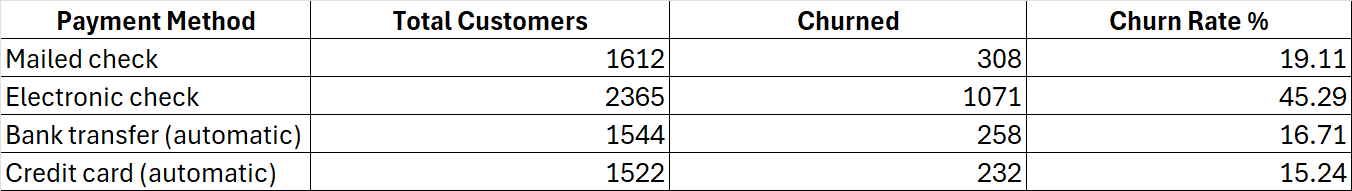

**Business Insights:**  
1. Electronic check payment customers are at risk with high churn rate - 45% which is almost half.
   - Customers are facing payment inconvinience.
   - Customers tend to be less committed to the services.
2. Customers with auto-payments and cashless payments are showing less churn rate.
   - Bank transfers (automatic) - 16.71 %
   - Credit Card (automatic) - 15.24 %

**Business Recommendations:**  
1. Promote cashless payments
   - Ensure customers that cashless and online payments are secure and simplified setups
   - Offer discounts or/and loyalty rewards on cashless and online payments.
2. Investigate electronic check payments
   - Payment issues in electronic checks
   - Offer some discounts and payments switching rewards for electronic check paying customers

**Customer Tenure Analysis**

In [214]:
# Create payment method aggregated data for visualization axis

payment_group = df.groupby("Payment Method")

total_customers = payment_group["CustomerID"].count()
churned_customers = payment_group["Churn Label"].apply(lambda x: (x == "Yes").sum())

payment_churn = pd.DataFrame({
    "Total Customers": total_customers,
    "Churned": churned_customers
})

payment_churn["Churn Rate (%)"] = (
    payment_churn["Churned"] / payment_churn["Total Customers"] * 100
)

payment_churn = payment_churn.reset_index()

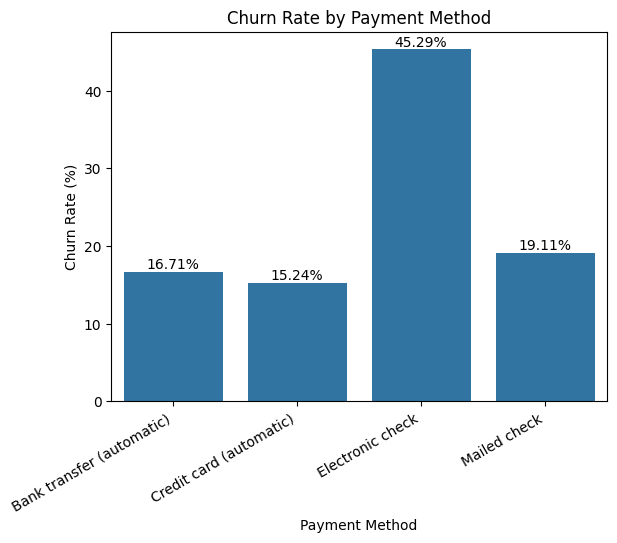

In [216]:
# Plotting graph for same

ax = sns.barplot(
    data=payment_churn,
    x="Payment Method",
    y="Churn Rate (%)"
)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30, ha='right')

plt.show()

In [95]:
# What are the values of tenures
df["Tenure Months"].unique()

array([ 2,  8, 28, 49, 10,  1, 47, 17,  5, 34, 11, 15, 18,  9,  7, 12, 25,
       68, 55, 37,  3, 27, 20,  4, 58, 53, 13,  6, 19, 59, 16, 52, 24, 32,
       38, 54, 43, 63, 21, 69, 22, 61, 60, 48, 40, 23, 39, 35, 56, 65, 33,
       30, 45, 46, 62, 70, 50, 44, 71, 26, 14, 41, 66, 64, 29, 42, 67, 51,
       31, 57, 36, 72,  0])

In [96]:
# Creating tenure buckets as per formula:

# 0–12 months	New customers
# 12–24 months	Early retention stage
# 24–48 months	Medium-term customers
# 48–72 months	Long-term customers

In [97]:
# Create new column "Tenure Group" and apply bins including the lowest value which is 0
df["Tenure Group"] = pd.cut(x=df["Tenure Months"],
                            bins=[0, 12, 24, 48, 72],
                            labels=["New customers", "Early retention stage", "Medium-term customers", "Long-term customers"],
                            include_lowest=True
                           )

In [98]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,Tenure Group
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer,New customers
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved,New customers
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved,New customers
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved,Medium-term customers
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices,Long-term customers


In [99]:
df["Tenure Group"].unique()

['New customers', 'Medium-term customers', 'Long-term customers', 'Early retention stage']
Categories (4, str): ['New customers' < 'Early retention stage' < 'Medium-term customers' < 'Long-term customers']

In [100]:
df["Tenure Group"].shape

(7043,)

In [101]:
df["Tenure Group"].value_counts()

Tenure Group
Long-term customers      2239
New customers            2186
Medium-term customers    1594
Early retention stage    1024
Name: count, dtype: int64

**Analysis: Tenure Group vs Churn**  
- Helps to understand average tenure before churn.
- If very high churn in first year
- Lower churn after customer loyalty forms

In [102]:
# Total customers in "New customers" tenure group
new_customers = len(df[df["Tenure Group"] == "New customers"])
new_customers

2186

In [103]:
# count of new customers and churned customers
new_customers_churn = len(df[(df["Tenure Group"] == "New customers") & (df["Churn Label"] == "Yes")])
new_customers_churn

1037

In [104]:
# Churn rate of this category
new_customers_churn_rate = round(((new_customers_churn / new_customers) * 100), 2)
new_customers_churn_rate

47.44

In [105]:
# Total customers in "Early retention stage" tenure group
early_retention_stage = len(df[df["Tenure Group"] == "Early retention stage"])
early_retention_stage

1024

In [106]:
# count of Early retention stage and churned customers
early_retention_stage_churn = len(df[(df["Tenure Group"] == "Early retention stage") & (df["Churn Label"] == "Yes")])
early_retention_stage_churn

294

In [107]:
# Churn rate of this category
early_retention_stage_churn_rate = round(((early_retention_stage_churn / early_retention_stage) * 100), 2)
early_retention_stage_churn_rate

28.71

In [108]:
# Total customers in "Medium-term customers" tenure group
medium_term_customers = len(df[df["Tenure Group"] == "Medium-term customers"])
medium_term_customers

1594

In [109]:
# count of Medium-term customers and churned customers
medium_term_customers_churn = len(df[(df["Tenure Group"] == "Medium-term customers") & (df["Churn Label"] == "Yes")])
medium_term_customers_churn

325

In [110]:
# Churn rate of this category
medium_term_customers_churn_rate = round(((medium_term_customers_churn / medium_term_customers) * 100), 2)
medium_term_customers_churn_rate

20.39

In [111]:
# Total customers in "Long-term customers" tenure group
long_term_customers = len(df[df["Tenure Group"] == "Long-term customers"])
long_term_customers

2239

In [112]:
# count of Medium-term customers and churned customers
long_term_customers_churn = len(df[(df["Tenure Group"] == "Long-term customers") & (df["Churn Label"] == "Yes")])
long_term_customers_churn

213

In [113]:
# Churn rate of this category
long_term_customers_churn_rate = round(((long_term_customers_churn / long_term_customers) * 100), 2)
long_term_customers_churn_rate

9.51

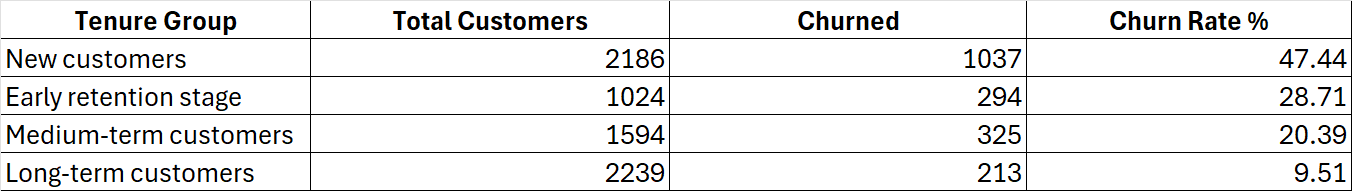

**Business Insights:**  
- Customers in the New customers (0–12 months) tenure group show the highest churn rate at 47.44%, meaning 1 out of 2 customers are leaving withing the first year of plan.
- Customer loyalty is increasing over time with early retention stage customers (12-24 months) tenure group having 28 %, medium-term customers (24-48 months) tenure group having 20 % and long-term customers (48-72 months) tenure group showing 9 % churn rate.

**Business Recommendation:**  
- Improve the customer on-boarding experience. High churn rate among new customers suggests following issue:
  - Unclear understanding of product and services.
  - Service offering issues during initial stage.
  - Expectations did not meet which were promised during on-boarding.
- Need to increase company's outreach with ad campaigns
  - Offer discounts on services bundles like 5 to 10 % more discount on current plan if purchased two year contract + fiber optic internet plan
  - Offer loyalty discounts when customers enter early rentention stage tenure group, medium-term and long-term tenure group.

**Service Feature Analysis:**  reveals product adoption effects on churn.  
**Customers who use more value-added services are often less likely to churn.**  

In [210]:
# Creating tenure group data churn

tenure_group = df.groupby("Tenure Group")

total_customers = tenure_group["CustomerID"].count()
churned_customers = tenure_group["Churn Label"].apply(lambda x: (x == "Yes").sum())

tenure_churn = pd.DataFrame({
    "Total Customers": total_customers,
    "Churned": churned_customers
})

tenure_churn["Churn Rate (%)"] = (
    tenure_churn["Churned"] / tenure_churn["Total Customers"] * 100
)

tenure_churn = tenure_churn.reset_index()

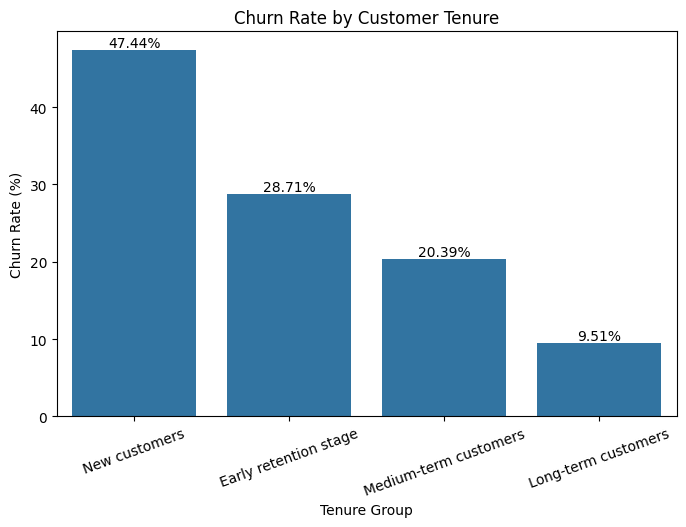

In [213]:
# Chart visualization
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=tenure_churn,
    x="Tenure Group",
    y="Churn Rate (%)"
)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)

plt.show()

In [114]:
# Identify Service Features
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason', 'Tenure Group'],
      dtype='str')

Services like **'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies'** are value added services

**Tech Support** service impact

In [115]:
df["Tech Support"].unique()

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [116]:
# Customers using Tech Support services
tech_support_service = len(df[df["Tech Support"] == "Yes"])
tech_support_service

2044

In [117]:
# Customers using tech support service and churned customers count
tech_support_churn = len(df[(df["Tech Support"] == "Yes") & (df["Churn Label"] == "Yes")])
tech_support_churn

310

In [118]:
# Churn rate for this category
tech_support_churn_rate = round(((tech_support_churn / tech_support_service) * 100), 2)
tech_support_churn_rate

15.17

In [119]:
# Customers not using Tech Support services
no_tech_support_service = len(df[df["Tech Support"] == "No"])
no_tech_support_service

3473

In [120]:
# Customers not using tech support service and churned customers count
no_tech_support_churn = len(df[(df["Tech Support"] == "No") & (df["Churn Label"] == "Yes")])
no_tech_support_churn

1446

In [121]:
# Churn rate for this category
no_tech_support_churn_rate = round(((no_tech_support_churn / no_tech_support_service) * 100), 2)
no_tech_support_churn_rate

41.64

In [122]:
# Tech support services count with "No internet service"
no_internet_tech_support_service = len(df[df["Tech Support"] == "No internet service"])
no_internet_tech_support_service

1526

In [123]:
# Customers with no internet tech support service and churned customers count
no_internet_tech_support_churn = len(df[(df["Tech Support"] == "No internet service") & (df["Churn Label"] == "Yes")])
no_internet_tech_support_churn

113

In [124]:
# Churn rate for this category
no_internet_tech_support_churn_rate = round(((no_internet_tech_support_churn / no_internet_tech_support_service) * 100), 2)
no_internet_tech_support_churn_rate

7.4

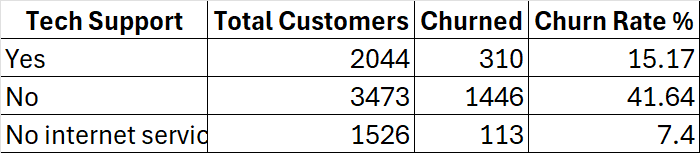

In [223]:
# Creating aggregation for tech support date
tech_group = df.groupby("Tech Support")

total_customers = tech_group["CustomerID"].count()
churned_customers = tech_group["Churn Label"].apply(lambda x: (x == "Yes").sum())

tech_churn = pd.DataFrame({
    "Total Customers": total_customers,
    "Churned": churned_customers
})

tech_churn["Churn Rate (%)"] = (
    tech_churn["Churned"] / tech_churn["Total Customers"] * 100
)

tech_churn = tech_churn.reset_index()

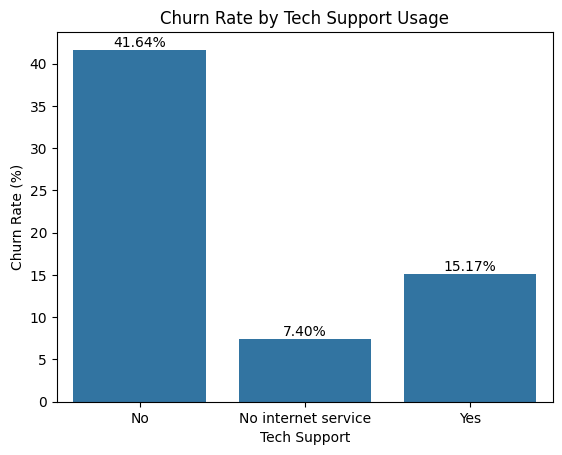

In [224]:
# Plotting graph with aggregated data
ax = sns.barplot(
    data=tech_churn,
    x="Tech Support",
    y="Churn Rate (%)"
)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title("Churn Rate by Tech Support Usage")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")

plt.show()

**Online Security** service impact

In [125]:
df["Online Security"].unique()

<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

In [126]:
# Customers subscribed to Online Security
online_security_customers = len(df[df["Online Security"] == "Yes"])
online_security_customers

2019

In [127]:
# Online security + churn count
online_security_churn = len(df[(df["Online Security"] == "Yes") & (df["Churn Label"] == "Yes")])
online_security_churn

295

In [128]:
# churn rate of such category
online_security_churn_rate = round(((online_security_churn / online_security_customers) * 100), 2)
online_security_churn_rate

14.61

In [129]:
# Customers no subscribed to Online Security
no_online_security_customers = len(df[df["Online Security"] == "No"])
no_online_security_customers

3498

In [130]:
# No Online security + churn count
no_online_security_churn = len(df[(df["Online Security"] == "No") & (df["Churn Label"] == "Yes")])
no_online_security_churn

1461

In [131]:
# churn rate of such category
no_online_security_churn_rate = round(((no_online_security_churn / no_online_security_customers) * 100), 2)
no_online_security_churn_rate

41.77

In [132]:
# Customers with no internet service (Online Security)
no_internet_online_security_customers = len(df[df["Online Security"] == "No internet service"])
no_internet_online_security_customers

1526

In [133]:
# No Internet service + churn count
no_internet_online_security_customers_churn = len(df[(df["Online Security"] == "No internet service") & (df["Churn Label"] == "Yes")])
no_internet_online_security_customers_churn

113

In [134]:
# churn rate of such category
no_internet_online_security_customers_churn_rate = round(((no_internet_online_security_customers_churn / no_internet_online_security_customers) * 100), 2)
no_internet_online_security_customers_churn_rate

7.4

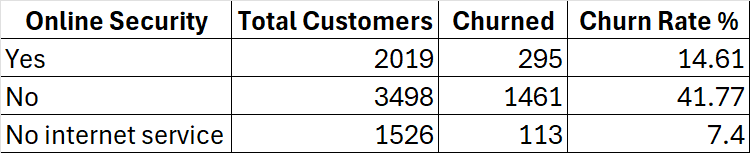

**Online Backup** service impact

In [135]:
df["Online Backup"].unique()

<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

In [136]:
# Customers subscribed to Online Backup
online_backup_customers = len(df[df["Online Backup"] == "Yes"])
online_backup_customers

2429

In [137]:
# Online Backup service + churn count
online_backup_customers_churn = len(df[(df["Online Backup"] == "Yes") & (df["Churn Label"] == "Yes")])
online_backup_customers_churn

523

In [138]:
# churn rate of such category
online_backup_customers_churn_rate = round(((online_backup_customers_churn / online_backup_customers) * 100), 2)
online_backup_customers_churn_rate

21.53

In [139]:
# Customers not subscribed to Online Backup
no_online_backup_customers = len(df[df["Online Backup"] == "No"])
no_online_backup_customers

3088

In [140]:
# No Online Backup service + churn count
no_online_backup_customers_churn = len(df[(df["Online Backup"] == "No") & (df["Churn Label"] == "Yes")])
no_online_backup_customers_churn

1233

In [141]:
# churn rate of such category
no_online_backup_customers_churn_rate = round(((no_online_backup_customers_churn / no_online_backup_customers) * 100), 2)
no_online_backup_customers_churn_rate

39.93

In [142]:
# Customers with no internet service (Online Backup)
no_internet_online_backup_customers = len(df[df["Online Backup"] == "No internet service"])
no_internet_online_backup_customers

1526

In [143]:
# no internet service (Online Backup) + churn count
no_internet_online_backup_customers_churn = len(df[(df["Online Backup"] == "No internet service") & (df["Churn Label"] == "Yes")])
no_internet_online_backup_customers_churn

113

In [144]:
# churn rate of such category
no_internet_online_backup_customers_churn_rate = round(((no_internet_online_backup_customers_churn / no_internet_online_backup_customers) * 100), 2)
no_internet_online_backup_customers_churn_rate

7.4

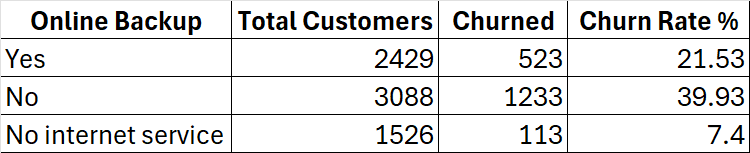

**Device Protection** service impact

In [145]:
df["Device Protection"].unique()

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [146]:
# Customers who have opted for Device Protection service
device_protection_customers = len(df[df["Device Protection"] == "Yes"])
device_protection_customers

2422

In [147]:
# Device Protection service + churn count
device_protection_customers_churn = len(df[(df["Device Protection"] == "Yes") & (df["Churn Label"] == "Yes")])
device_protection_customers_churn

545

In [148]:
# Churn rate of such category
device_protection_customers_churn_rate = round(((device_protection_customers_churn / device_protection_customers) * 100), 2)
device_protection_customers_churn_rate

22.5

In [149]:
# Customers who have not opted for Device Protection service
no_device_protection_customers = len(df[df["Device Protection"] == "No"])
no_device_protection_customers

3095

In [150]:
# No Device Protection service + churn count
no_device_protection_customers_churn = len(df[(df["Device Protection"] == "No") & (df["Churn Label"] == "Yes")])
no_device_protection_customers_churn

1211

In [151]:
# Churn rate of such category
no_device_protection_customers_churn_rate = round(((no_device_protection_customers_churn / no_device_protection_customers) * 100), 2)
no_device_protection_customers_churn_rate

39.13

In [152]:
# Customers who don't have internet service (Device Protection service)
no_internet_device_protection_customers = len(df[df["Device Protection"] == "No internet service"])
no_internet_device_protection_customers

1526

In [153]:
# No internet service (Device Protection service) + churn count
no_internet_device_protection_customers_churn = len(df[(df["Device Protection"] == "No internet service") & (df["Churn Label"] == "Yes")])
no_internet_device_protection_customers_churn

113

In [154]:
# Churn rate of such category
no_internet_device_protection_customers_churn_rate = round(((no_internet_device_protection_customers_churn / no_internet_device_protection_customers) * 100), 2)
no_internet_device_protection_customers_churn_rate

7.4

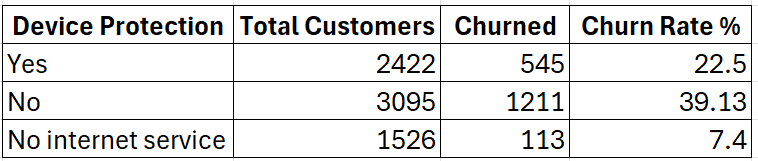

**Streaming TV** service impact

In [155]:
df["Streaming TV"].unique()

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [156]:
# Customers who opted for streaming TV service
streaming_tv_customers = len(df[df["Streaming TV"] == "Yes"])
streaming_tv_customers

2707

In [157]:
# Customers with streaming TV services + churn
streaming_tv_customers_churn = len(df[(df["Streaming TV"] == "Yes") & (df["Churn Label"] == "Yes")])
streaming_tv_customers_churn

814

In [158]:
# Churn rate for such category
streaming_tv_customers_churn_rate = round(((streaming_tv_customers_churn / streaming_tv_customers) * 100), 2)
streaming_tv_customers_churn_rate

30.07

In [159]:
# Customers who have not opted for streaming TV service
no_streaming_tv_customers = len(df[df["Streaming TV"] == "No"])
no_streaming_tv_customers

2810

In [160]:
# Customers with no streaming TV services + churn
no_streaming_tv_customers_churn = len(df[(df["Streaming TV"] == "No") & (df["Churn Label"] == "Yes")])
no_streaming_tv_customers_churn

942

In [161]:
# Churn rate for such category
no_streaming_tv_customers_churn_rate = round(((no_streaming_tv_customers_churn / no_streaming_tv_customers) * 100), 2)
no_streaming_tv_customers_churn_rate

33.52

In [162]:
# Customers who don't have internet service (streaming TV service)
no_internet_streaming_tv_customers = len(df[df["Streaming TV"] == "No internet service"])
no_internet_streaming_tv_customers

1526

In [163]:
# Customers with no internet service (streaming TV service) + churn
no_internet_streaming_tv_customers_churn = len(df[(df["Streaming TV"] == "No internet service") & (df["Churn Label"] == "Yes")])
no_internet_streaming_tv_customers_churn

113

In [164]:
# Churn rate for such category
no_internet_streaming_tv_customers_churn_rate = round(((no_internet_streaming_tv_customers_churn / no_internet_streaming_tv_customers) * 100), 2)
no_internet_streaming_tv_customers_churn_rate

7.4

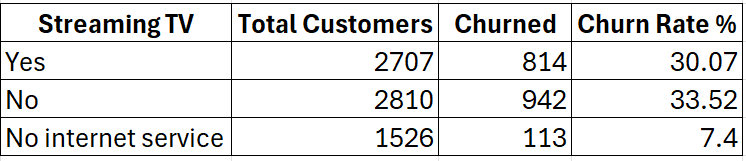

**Streaming Movies** service impact

In [165]:
df["Streaming Movies"].unique()

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [166]:
# Customers who opted for streaming movies service
streaming_movies_customers = len(df[df["Streaming Movies"] == "Yes"])
streaming_movies_customers

2732

In [167]:
# Customers with streaming TV movies + churn
streaming_movies_customers_churn = len(df[(df["Streaming Movies"] == "Yes") & (df["Churn Label"] == "Yes")])
streaming_movies_customers_churn

818

In [168]:
# Churn rate for such category
streaming_movies_customers_churn_rate = round(((streaming_movies_customers_churn / streaming_movies_customers) * 100), 2)
streaming_movies_customers_churn_rate

29.94

In [169]:
# Customers who have not opted for streaming movies service
no_streaming_movies_customers = len(df[df["Streaming Movies"] == "No"])
no_streaming_movies_customers

2785

In [170]:
# Customers have not opted for streaming movies service + churn
no_streaming_movies_customers_churn = len(df[(df["Streaming Movies"] == "No") & (df["Churn Label"] == "Yes")])
no_streaming_movies_customers_churn

938

In [171]:
# Churn rate for such category
no_streaming_movies_customers_churn_rate = round(((no_streaming_movies_customers_churn / no_streaming_movies_customers) * 100), 2)
no_streaming_movies_customers_churn_rate

33.68

In [172]:
# Customers who don't have internet service (streaming movies service)
no_internet_streaming_movies_customers = len(df[df["Streaming Movies"] == "No internet service"])
no_internet_streaming_movies_customers

1526

In [173]:
# Customers with no internet service (streaming movies service) + churn
no_internet_streaming_movies_customers_churn = len(df[(df["Streaming Movies"] == "No internet service") & (df["Churn Label"] == "Yes")])
no_internet_streaming_movies_customers_churn

113

In [174]:
# Churn rate for such category
no_internet_streaming_movies_customers_churn_rate = round(((no_internet_streaming_movies_customers_churn / no_internet_streaming_movies_customers) * 100), 2)
no_internet_streaming_movies_customers_churn_rate

7.4

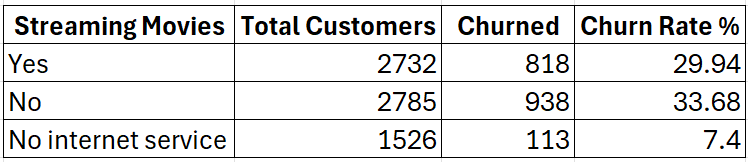

**Business Insights:**  
1. In overall view, customers who have adopted for value-add services like Tech Support, Online Security, Backup, and Device Protection are showing less churn rate compared to those who have not.
2. Customers without these services show consistently higher churn rates (35 - 40 %).
3. For entertainment services like Streaming movies and TV - customer churn rate has minimal impact since both categories show same churn rate for customers whether subscribed or not.

**Business Recommendations:**  
1. Encourage tech support service on priority basis which wil help customers resolve their issues thereby reducing overall churn rate.
2. Promote bundled Online services like tech support, security and backup by educating customers their importance thereby reducing churn probability.
3. Offer discounts and trial subscriptions on streaming services which would attract more customers.

### Identifying High-Risk Customer Segments

**High-Risk Segment 1 (Most Critical):**  Based on the numbers, highest churn rate customer segment were **Fiber optic internet service, Month-to-month contract type, Electronic check payment method, New customers group tenure (0-12 months) and no tech support services**

In [175]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason', 'Tenure Group'],
      dtype='str')

In [176]:
# Total customers present in the highest risk churn segment
highest_risk_churn_segment = len(df[(df["Internet Service"] == "Fiber optic") & (df["Contract"] == "Month-to-month") & (df["Payment Method"] == "Electronic check") & (df["Tenure Group"] == "New customers") & (df["Tech Support"] == "No")])
highest_risk_churn_segment

589

In [177]:
# Churn for total customers present in the highest risk churn segment
highest_risk_churn_segment_churn = len(df[(df["Internet Service"] == "Fiber optic") & (df["Contract"] == "Month-to-month") & (df["Payment Method"] == "Electronic check") & (df["Tenure Group"] == "New customers") & (df["Tech Support"] == "No") & (df["Churn Label"] == "Yes")])
highest_risk_churn_segment_churn

426

In [178]:
# Churn rate for this segment
highest_risk_churn_segment_churn_rate = round(((highest_risk_churn_segment_churn / highest_risk_churn_segment) * 100), 2)
highest_risk_churn_segment_churn_rate

72.33

**High-Risk Segment 2:** Identifying customer churn rate for high risk segment which includes **Month-to-month contract type, DSL internet services, No value-added services subscription, Early tenure group customers**

In [179]:
# Total customers present in the high risk churn segment
high_risk_churn_segment = len(df[(df["Internet Service"] == "DSL") & (df["Contract"] == "Month-to-month") & (df["Tenure Group"] == "Early retention stage")])
high_risk_churn_segment

232

In [180]:
# Churn for total customers present in the high risk churn segment
high_risk_churn_segment_churn = len(df[(df["Internet Service"] == "DSL") & (df["Contract"] == "Month-to-month") & (df["Tenure Group"] == "Early retention stage") & (df["Churn Label"] == "Yes")])
high_risk_churn_segment_churn

55

In [181]:
# Churn rate for this segment
high_risk_churn_segment_churn_rate = round(((high_risk_churn_segment_churn / high_risk_churn_segment) * 100), 2)
high_risk_churn_segment_churn_rate

23.71

**Low-Risk Segment:** Churn rate for customers with Two-year contract, Auto payment (credit card / bank transfer), Long-term customers, Using multiple services

In [182]:
# Total customers in low risk segment
low_risk_segment = len(df[(df["Contract"] == "Two year") & ((df["Payment Method"] == "Bank transfer (automatic)") | (df["Payment Method"] == "Credit card (automatic)")) & (df["Tenure Group"] == "Long-term customers") & (df["Tech Support"] == "Yes") & (df["Online Security"] == "Yes") & (df["Online Backup"] == "Yes") & (df["Device Protection"] == "Yes") & (df["Streaming TV"] == "Yes") & (df["Streaming Movies"] == "Yes")])
low_risk_segment

181

In [183]:
# Churn for low risk segment
low_risk_segment_churn = len(df[(df["Contract"] == "Two year") & ((df["Payment Method"] == "Bank transfer (automatic)") | (df["Payment Method"] == "Credit card (automatic)")) & (df["Tenure Group"] == "Long-term customers") & (df["Tech Support"] == "Yes") & (df["Online Security"] == "Yes") & (df["Online Backup"] == "Yes") & (df["Device Protection"] == "Yes") & (df["Streaming TV"] == "Yes") & (df["Streaming Movies"] == "Yes") & (df["Churn Label"] == "Yes")])
low_risk_segment_churn

4

In [184]:
# Churn rate for this segment
low_risk_segment_churn_rate = round(((low_risk_segment_churn / low_risk_segment) * 100), 2)
low_risk_segment_churn_rate

2.21

### Final Churn Driver Summary:

1. **Contract Type (Biggest churn rate driver)**  
   Customers who have opted for month-to-month basis contract type have significantly driven the churn rate compared to long term contract customers, posing as lack of commitment.
2. **Customer Tenure**  
   Among all the customers, the new customers (0-12 months) contribute the highest to churn rate (47.44 %) which shows lack in on-boarding experience or low customer satisfaction with company's product/services.
3. **Add on services adoption**  
   Customers who did not subscribe to value added services like tech support, online facilities and backup contribute to around 35-40 % churn rate, while customers using these services show comparitively less churn.
4. **High-Risk Segment**  
   The segments Fiber optic internet service + Month-to-month contract type + Electronic check payment method + New customers group tenure (0-12 months) + no tech support services customers are at highest risk to the company.

### Final Business Recommendations:

1. **Improve Customer Onboarding experience**  
   - Focus on new customers by:  
         - Good on-boarding experience and guided service activation.
         - Complimentary tech support to resolve any issues with respect to product throughout the first year of their onboarding
2. **Promote Long term contracts**
   - Offer discounts around 5-10 % of actual cost on long term contracts for new customers during on-boarding.
   - Encourage contract shift for month-to-month contract customers to one year or two year contracts.
3. **Promote Auto-payments**
   - Promote cashless payments to customers justifying the ease of payment and secure transactions.
   - Offer small biling discounts on auto-payment methods.
4. **Offer bundled add-on servicess**
   - Offer bundled security add on services like security and backup along with contracts at minimal cost.
   - Offer free one month trial period and "unsubscribe anytime" feature for streaming services like TV and movies.
   - Promote the importance of device protection service and how it could help customers secure their devices.
5. **Target highest risk customer segment**
   - Customers with fiber internet service + month-to-month contract are at highest risk, encourage them to switch to long term contracts by offering small discounts.
   - Encourage the benefit of tech support services to resolve any issues post service activation and throughout customer lifecycle.
   - Encourage auto-payments and electronic payments by advertising safe and seamless transactions.

## Project Summary

### 1. Business Problem
The telecom company is experiencing a high churn rate (25-30%), leading to a exponential loss in revenue and increase in customer acquistion costs. There is a need to identify key factors contributing to the customer churn, business revenue loss and derive data-driven business recommendations to control the customer churn and improve company revenue.

### 2. Objective
1. List out the key metrics that are driving the customer churn.
2. Identify the high risk and low risk segments for the churn.
3. Provide business recommendation on reducing churn and improve revenues.

### 3. Key Findings
1. Customers who opted for month-to-month contracts have significantly driven the churn rate compared to long term contract customers, indicating lack of commitment.
2. Among the customers, the new customers (0-12 months) contribute the most to churn rate (47.44 %) which shows a gap in on-boarding experience and early stage customer group satisfaction.
3. Customers who do not subscribe to value added services like tech support, online facilities and backup show higher churn rate (35-40%), compared to those who use them show low churn rate.
4. The customer segment of Fiber optic internet service + Month-to-month contract type + Electronic check payment method + New customers group tenure (0-12 months) + no tech support services are at high risk to the company.

### 4. Business Impact
1. High churn rate reduces the customer lifetime value (CLV) of the company.
2. Customer acquistion costs (CAC) significantly increase with increase in churn rate.

### 5. Business Recommendations
1. Improve customer onboarding experience through guided service activation and proactive tech support.
2. Encourage customers on opting for long term contracts by offering small discounts and upgrade incentives.
3. Offer bundled value-added services and trial periods on streaming services.
4. Promote auto-payment methods and cashless online payment methods highlighting the ease, secure and seamless method of transaction.
5. Target high risk segment customers with personalized strategies and offers for retention.

### 6. Expected Outcomes
1. Reduction in churn rate.
2. Business revenue balanced.
3. Customer retention and lifetime value improved.
4. Increase in value-added services adoption.